###### This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Proyecto de Regresion Lineal

Predicción de Precios de Viviendas: Utiliza regresión lineal para predecir los precios de las viviendas en función de características como el tamaño, la ubicación y el número de habitaciones.

## Dataset:

California Housing Prices

DataFrame sin ninguna modificación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = pd.read_csv('/kaggle/input/california-housing-prices/housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Limpieza de datos del DF ##

* Cambio la variables categóricas por clasificaciones numéricas
* Exploración de los datos
* Remuevo valores nulos y valores extremos

In [2]:
#Identifica las columnas con datos de categorias (Ej. 'ocean_proximity')
cat_cols = df.select_dtypes(include=['object']).columns

# Ciclo for para aplicar label encoding-cambia las categorias por clasificasiones numericas
for cat in cat_cols:
    print(f' Los valores de la col {cat} son {df[cat].unique()}')
    df[cat] = le.fit_transform(df[cat])
    print(f'se cambiaron por {df[cat].unique()}')
    

 Los valores de la col ocean_proximity son ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']
se cambiaron por [3 0 1 4 2]


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.6 MB


In [4]:
# Descripcion genereal de los datos

df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,1.165843
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,1.420662
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,1.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,1.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,4.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'ocean_proximity'}>, <Axes: >, <Axes: >]],
      dtype=object)

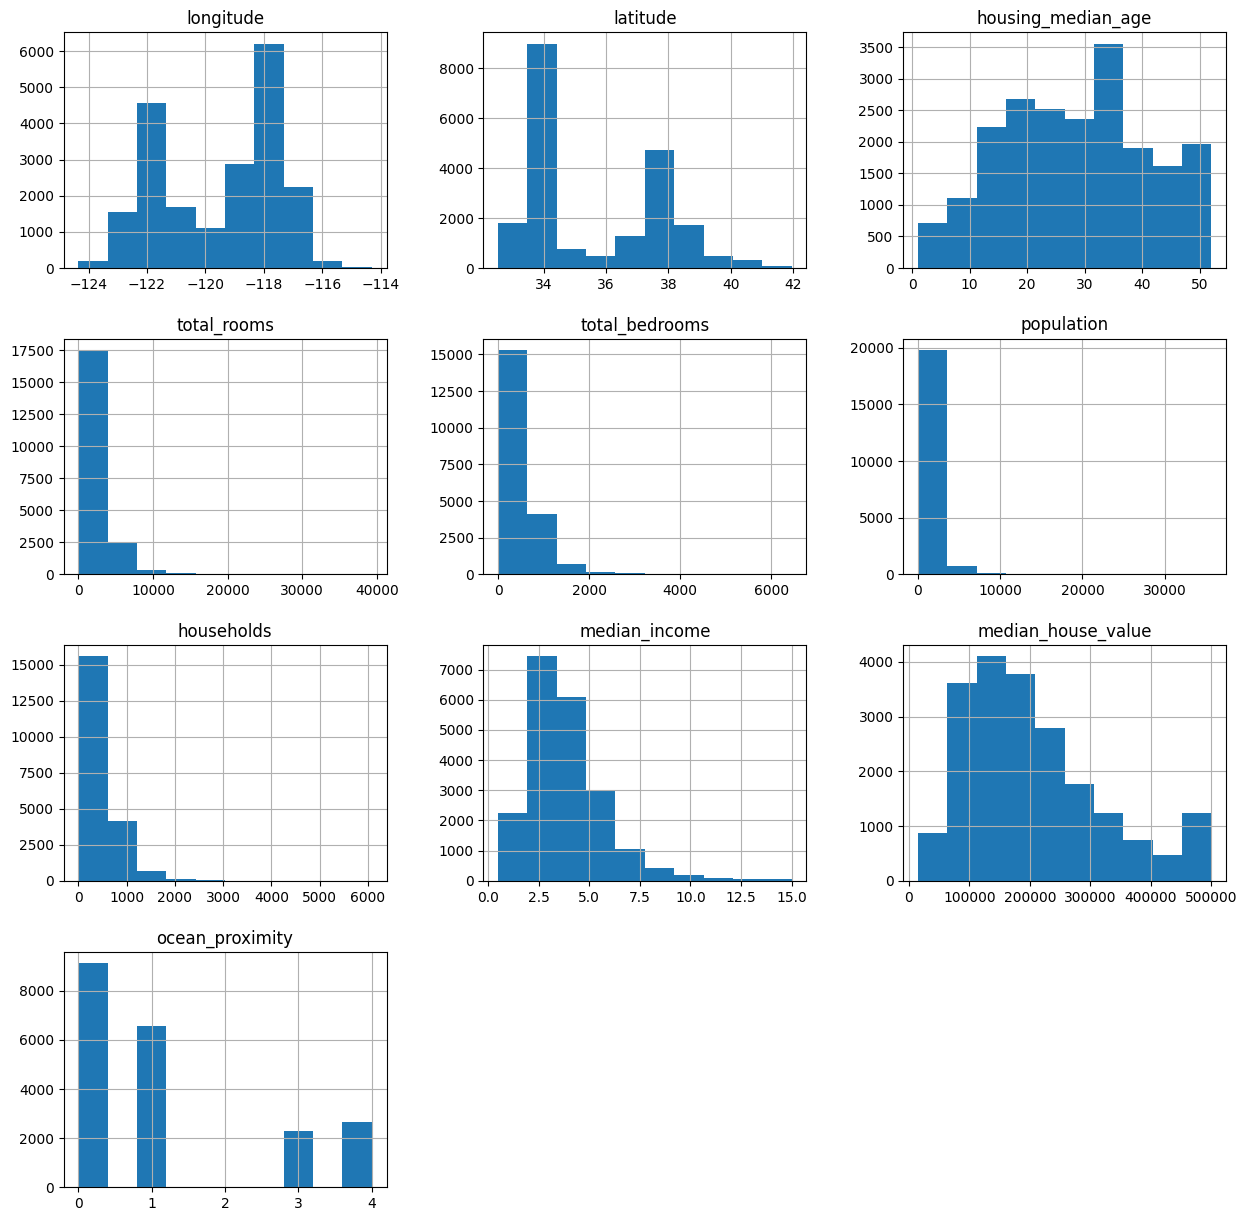

In [5]:
# Grafico las distrbuciones de cada variable
df.hist(figsize=(15,15))

**Observación**

Las variables **"total_rooms"**, **"total_bedrooms"**, **"population"** y **"household"** presentan distribuciones muy similares, con poblaciones practiacemente despreciables con valores extremos muy grandes. 
Voy a remover esas poblaciones de la muestra final de datos.

**El 75%** de los datos tienen **"total_bedroom < 647"**.El **máximo valor** de esta variable es **6445**. Por lo tanto ese 25% presenta una gran disperción entre sus valores. Eliminarlo mejorará la calidad de los datos y no perderé un volúmen muy grande de ellos.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'ocean_proximity'}>, <Axes: >, <Axes: >]],
      dtype=object)

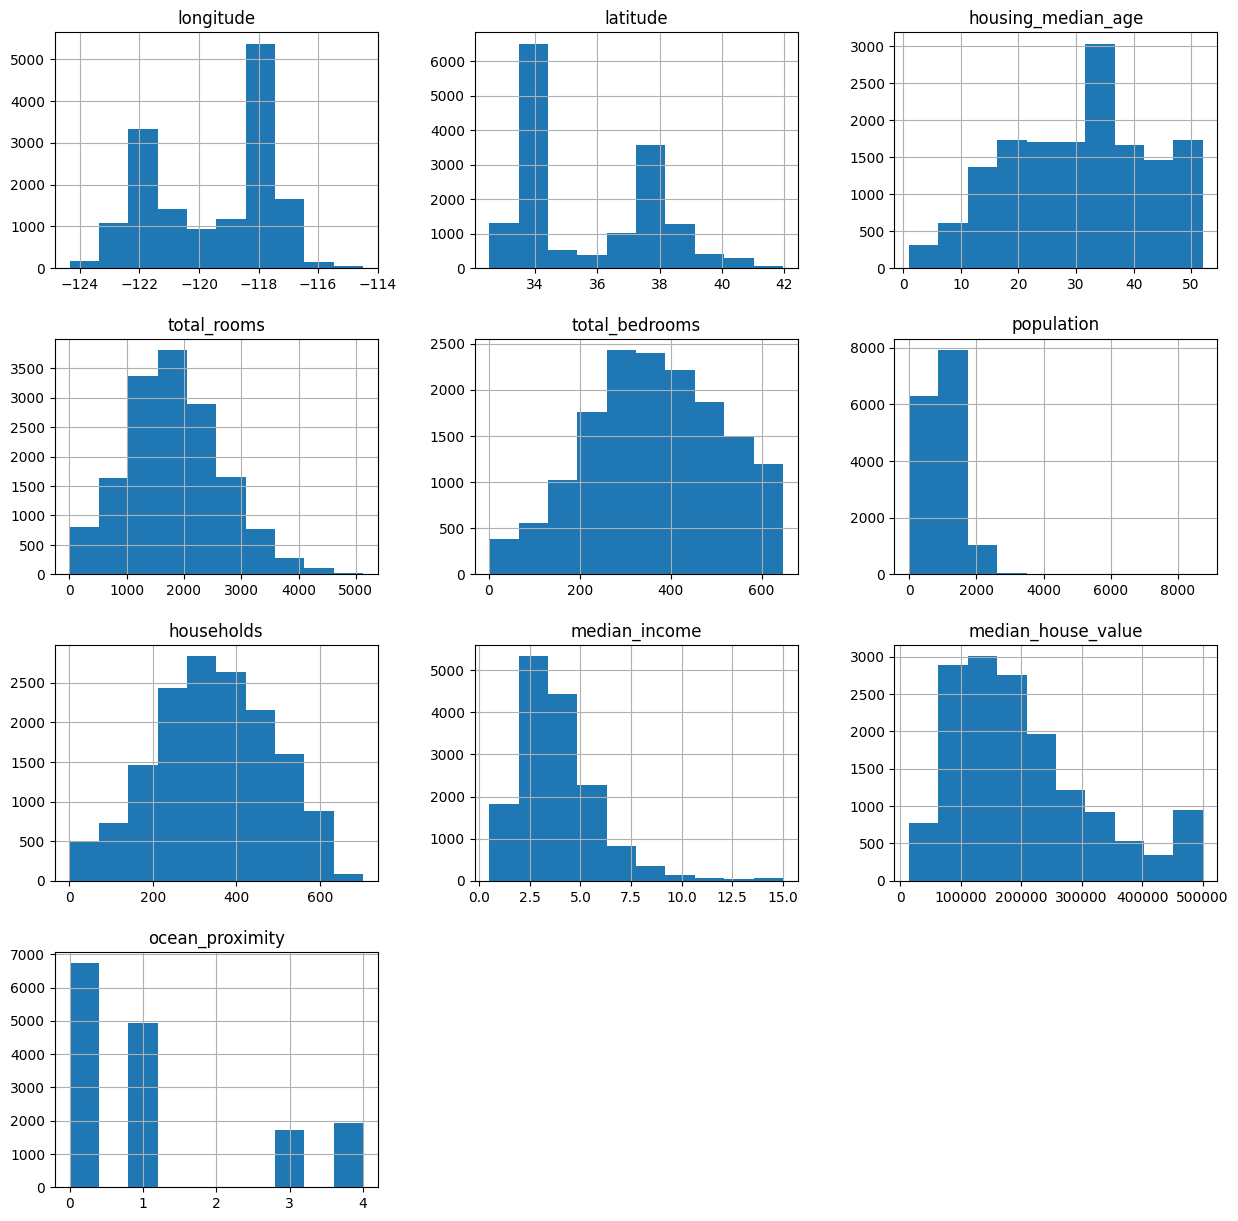

In [6]:
mask = df['total_bedrooms'] <= 647.
df = df[mask]

#Grafico las distribuciones sin estos datos
df.hist(figsize=(15,15))

La variable 'population' continua presentando una dispercion considerable para valores grandes. 

**Elimino** los datos con **population > 2000**, para quedarme con el último *bin* significativo de la distribución.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'ocean_proximity'}>, <Axes: >, <Axes: >]],
      dtype=object)

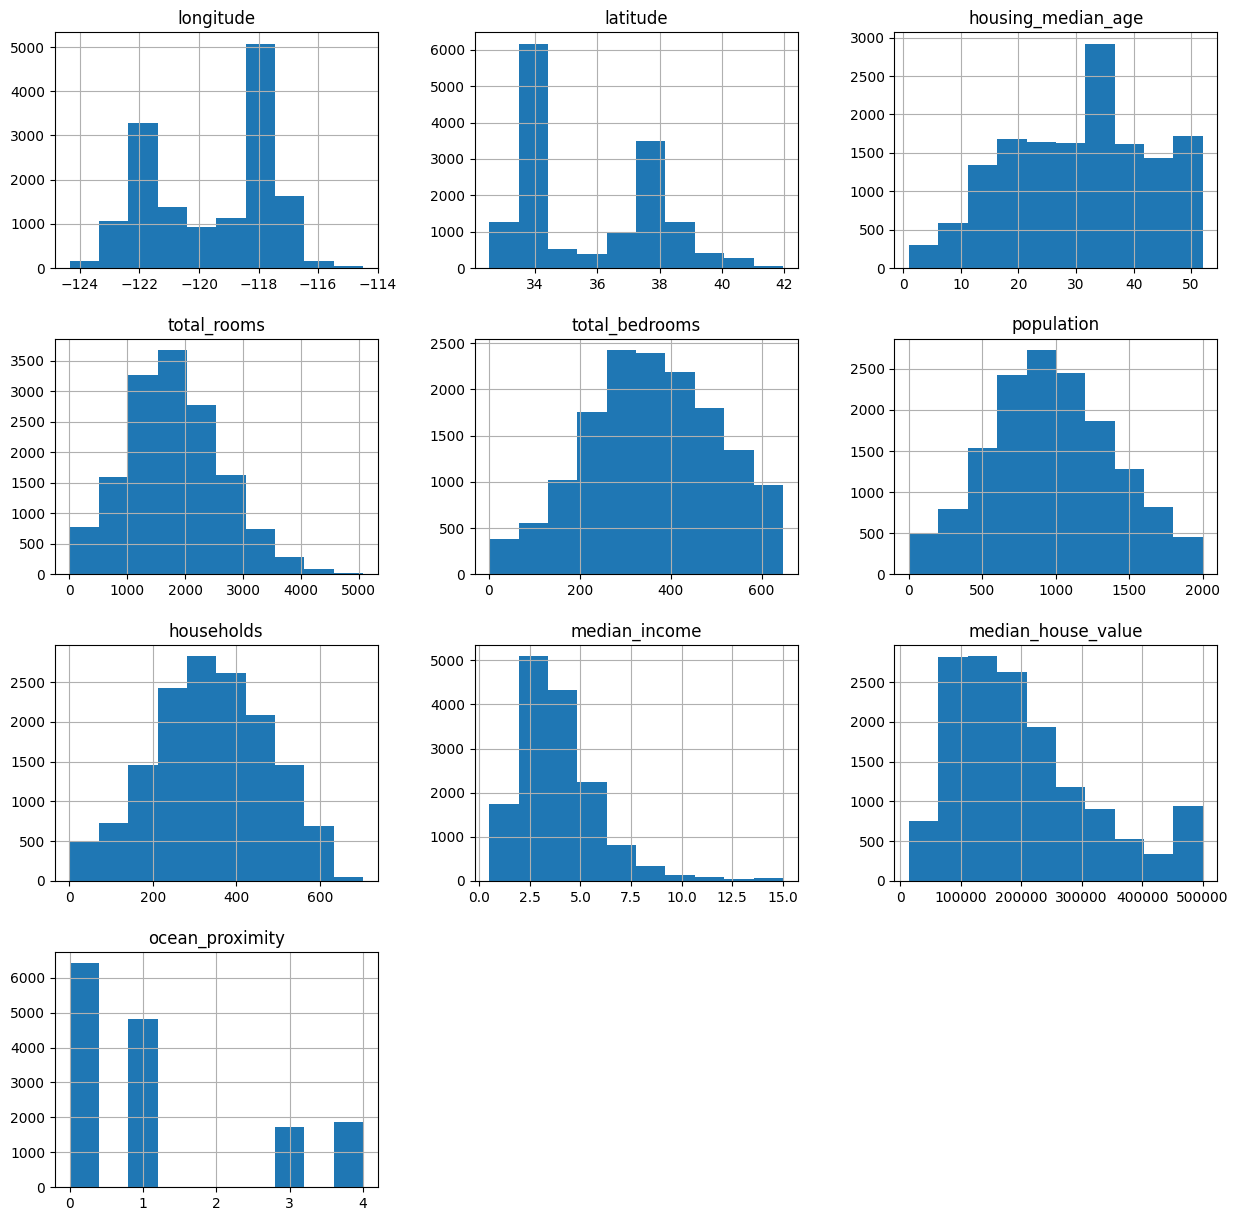

In [7]:
mask = df['population'] <= 2000.
df = df[mask]

#Grafico nuevamente las distribuciones sin estos datos
df.hist(figsize=(15,15))

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,14846.000000,14846.000000,14846.000000,14846.000000,14846.000000,14846.000000,14846.000000,14846.000000,14846.000000,14846.000000
mean,-119.651983,35.729264,30.812407,1814.594301,358.613835,978.073353,338.460932,3.920543,204623.314832,1.177354
std,2.004748,2.165294,12.264906,822.020114,144.127759,423.887289,137.431663,1.984500,117777.490324,1.414309
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000
25%,-121.830000,33.940000,21.000000,1250.000000,259.000000,683.000000,244.000000,2.541700,113525.000000,0.000000
50%,-118.850000,34.420000,32.000000,1755.000000,357.000000,959.000000,338.000000,3.585000,176100.000000,1.000000
75%,-118.060000,37.750000,39.000000,2341.000000,467.000000,1273.000000,439.000000,4.833300,263300.000000,1.000000
max,-114.490000,41.950000,52.000000,5077.000000,647.000000,2000.000000,703.000000,15.000100,500001.000000,4.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14846 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14846 non-null  float64
 1   latitude            14846 non-null  float64
 2   housing_median_age  14846 non-null  float64
 3   total_rooms         14846 non-null  float64
 4   total_bedrooms      14846 non-null  float64
 5   population          14846 non-null  float64
 6   households          14846 non-null  float64
 7   median_income       14846 non-null  float64
 8   median_house_value  14846 non-null  float64
 9   ocean_proximity     14846 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


# Prueba de modelos #

Pruebo diferentes modelos de redes neuronales para ver cual es el que consigue la mejor aproximación de "median_house_value"

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor  # Importación para XGBoost
from catboost import CatBoostRegressor  # Importación para CatBoost
from lightgbm import LGBMRegressor  # Importación para LightGBM
from sklearn.neural_network import MLPRegressor  # Importación para MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Crear una lista de modelos
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Lasso Regression', Lasso()),
    ('Decision Tree Regressor', DecisionTreeRegressor()),
    ('Random Forest Regressor', RandomForestRegressor()),
    ('Gradient Boosting Regressor', GradientBoostingRegressor()),
    ('SVR', SVR()),
    ('XGBoost Regressor', XGBRegressor()),  # Nuevo modelo XGBoost
    ('CatBoost Regressor', CatBoostRegressor(verbose=False)),  # Nuevo modelo CatBoost
    ('LightGBM Regressor', LGBMRegressor()),  # Nuevo modelo LightGBM
    ('MLP Regressor', MLPRegressor())  # Nuevo modelo MLPRegressor
]


In [11]:
# Defino X=varaibles independientes(parametros p/prediccion) y=variable dependiente (a predecir)

X = df.drop(['median_house_value'], axis=1)#Por ahora uso todos, cuando defina un modelo voy a mejorar la seleccion

y = df['median_house_value']

In [12]:
#Entreno con el 80% de los datos
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=420)

In [13]:
# Crear un diccionario para almacenar las métricas
metrics_dict = {'Model': [], 'MAE': [], 'R^2': []}

# Iterar sobre los modelos
for model_name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Imprimir resultados en la consola
    print(f'Model: {model_name}')
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'R-squared (R^2): {r2}')
    print('-' * 40)
    
    # Almacenar métricas en el diccionario
    metrics_dict['Model'].append(model_name)
    metrics_dict['MAE'].append(mae)
    metrics_dict['R^2'].append(r2)

Model: Linear Regression
Mean Absolute Error (MAE): 49677.58562374383
R-squared (R^2): 0.666249988257027
----------------------------------------
Model: Ridge Regression
Mean Absolute Error (MAE): 49677.460388938096
R-squared (R^2): 0.6662486934493422
----------------------------------------
Model: Lasso Regression
Mean Absolute Error (MAE): 49677.55092102895
R-squared (R^2): 0.6662498892538027
----------------------------------------
Model: Decision Tree Regressor
Mean Absolute Error (MAE): 45618.42457912458
R-squared (R^2): 0.6247269588862718
----------------------------------------
Model: Random Forest Regressor
Mean Absolute Error (MAE): 33496.36855892256
R-squared (R^2): 0.8043713235790579
----------------------------------------
Model: Gradient Boosting Regressor
Mean Absolute Error (MAE): 38937.33337274218
R-squared (R^2): 0.7710183821872113
----------------------------------------
Model: SVR
Mean Absolute Error (MAE): 90180.31727471217
R-squared (R^2): -0.06211048759352855
----

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


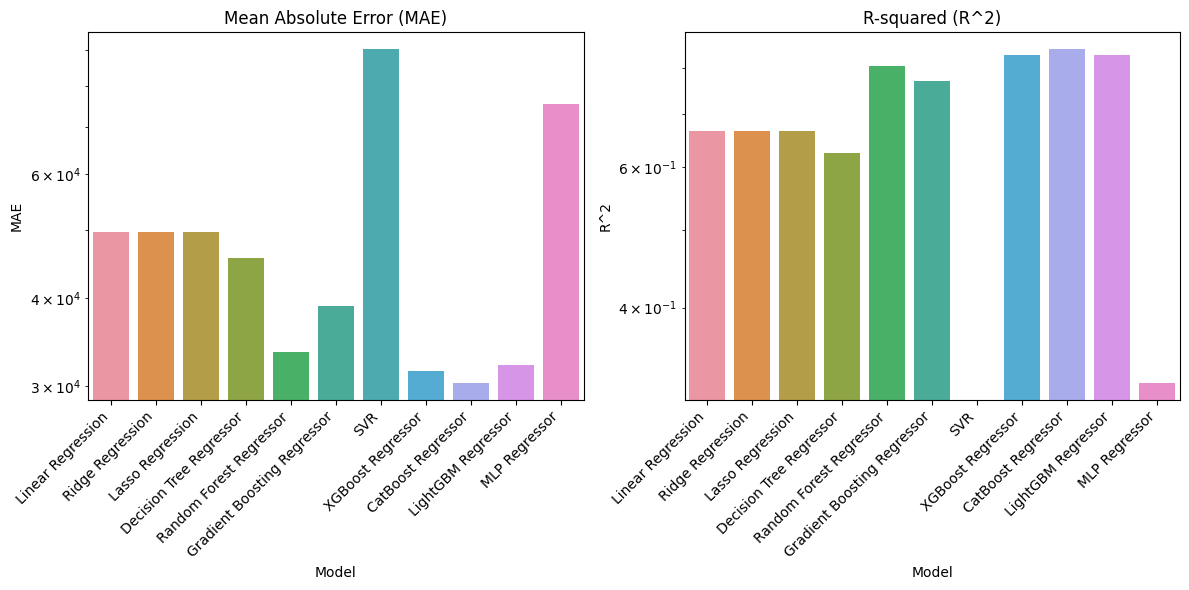

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir el diccionario a un DataFrame de pandas
metrics_df = pd.DataFrame(metrics_dict)

# Graficar las métricas
plt.figure(figsize=(12, 6))

# Barplot para MAE
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MAE', data=metrics_df)
plt.title('Mean Absolute Error (MAE)')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas para mejorar la legibilidad
plt.yscale('log')  # Escala logarítmica en el eje y para MAE

# Barplot para R^2
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R^2', data=metrics_df)
plt.title('R-squared (R^2)')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas para mejorar la legibilidad
plt.yscale('log')  # Escala logarítmica en el eje y para R^2

# Ajustar diseño
plt.tight_layout()
plt.show()


## Conclusión ##

El modelo CatBoost Regressor es el que mayor presición alcanza. Logra predecir los valores de 'median_house_value' con un error del orden de $\sim 30.000$ dolares sin usando todos los parámetros y sin combinarlos.

El SVR es el menos preciso de todos los modelos evaluados

## MEJORANDO EL MODELO

Utilizando unicamente CatBoost Regressor busco mejorar los resultados eligiendo mejor los datos con los que entreno la red o combinándolos. 

In [15]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


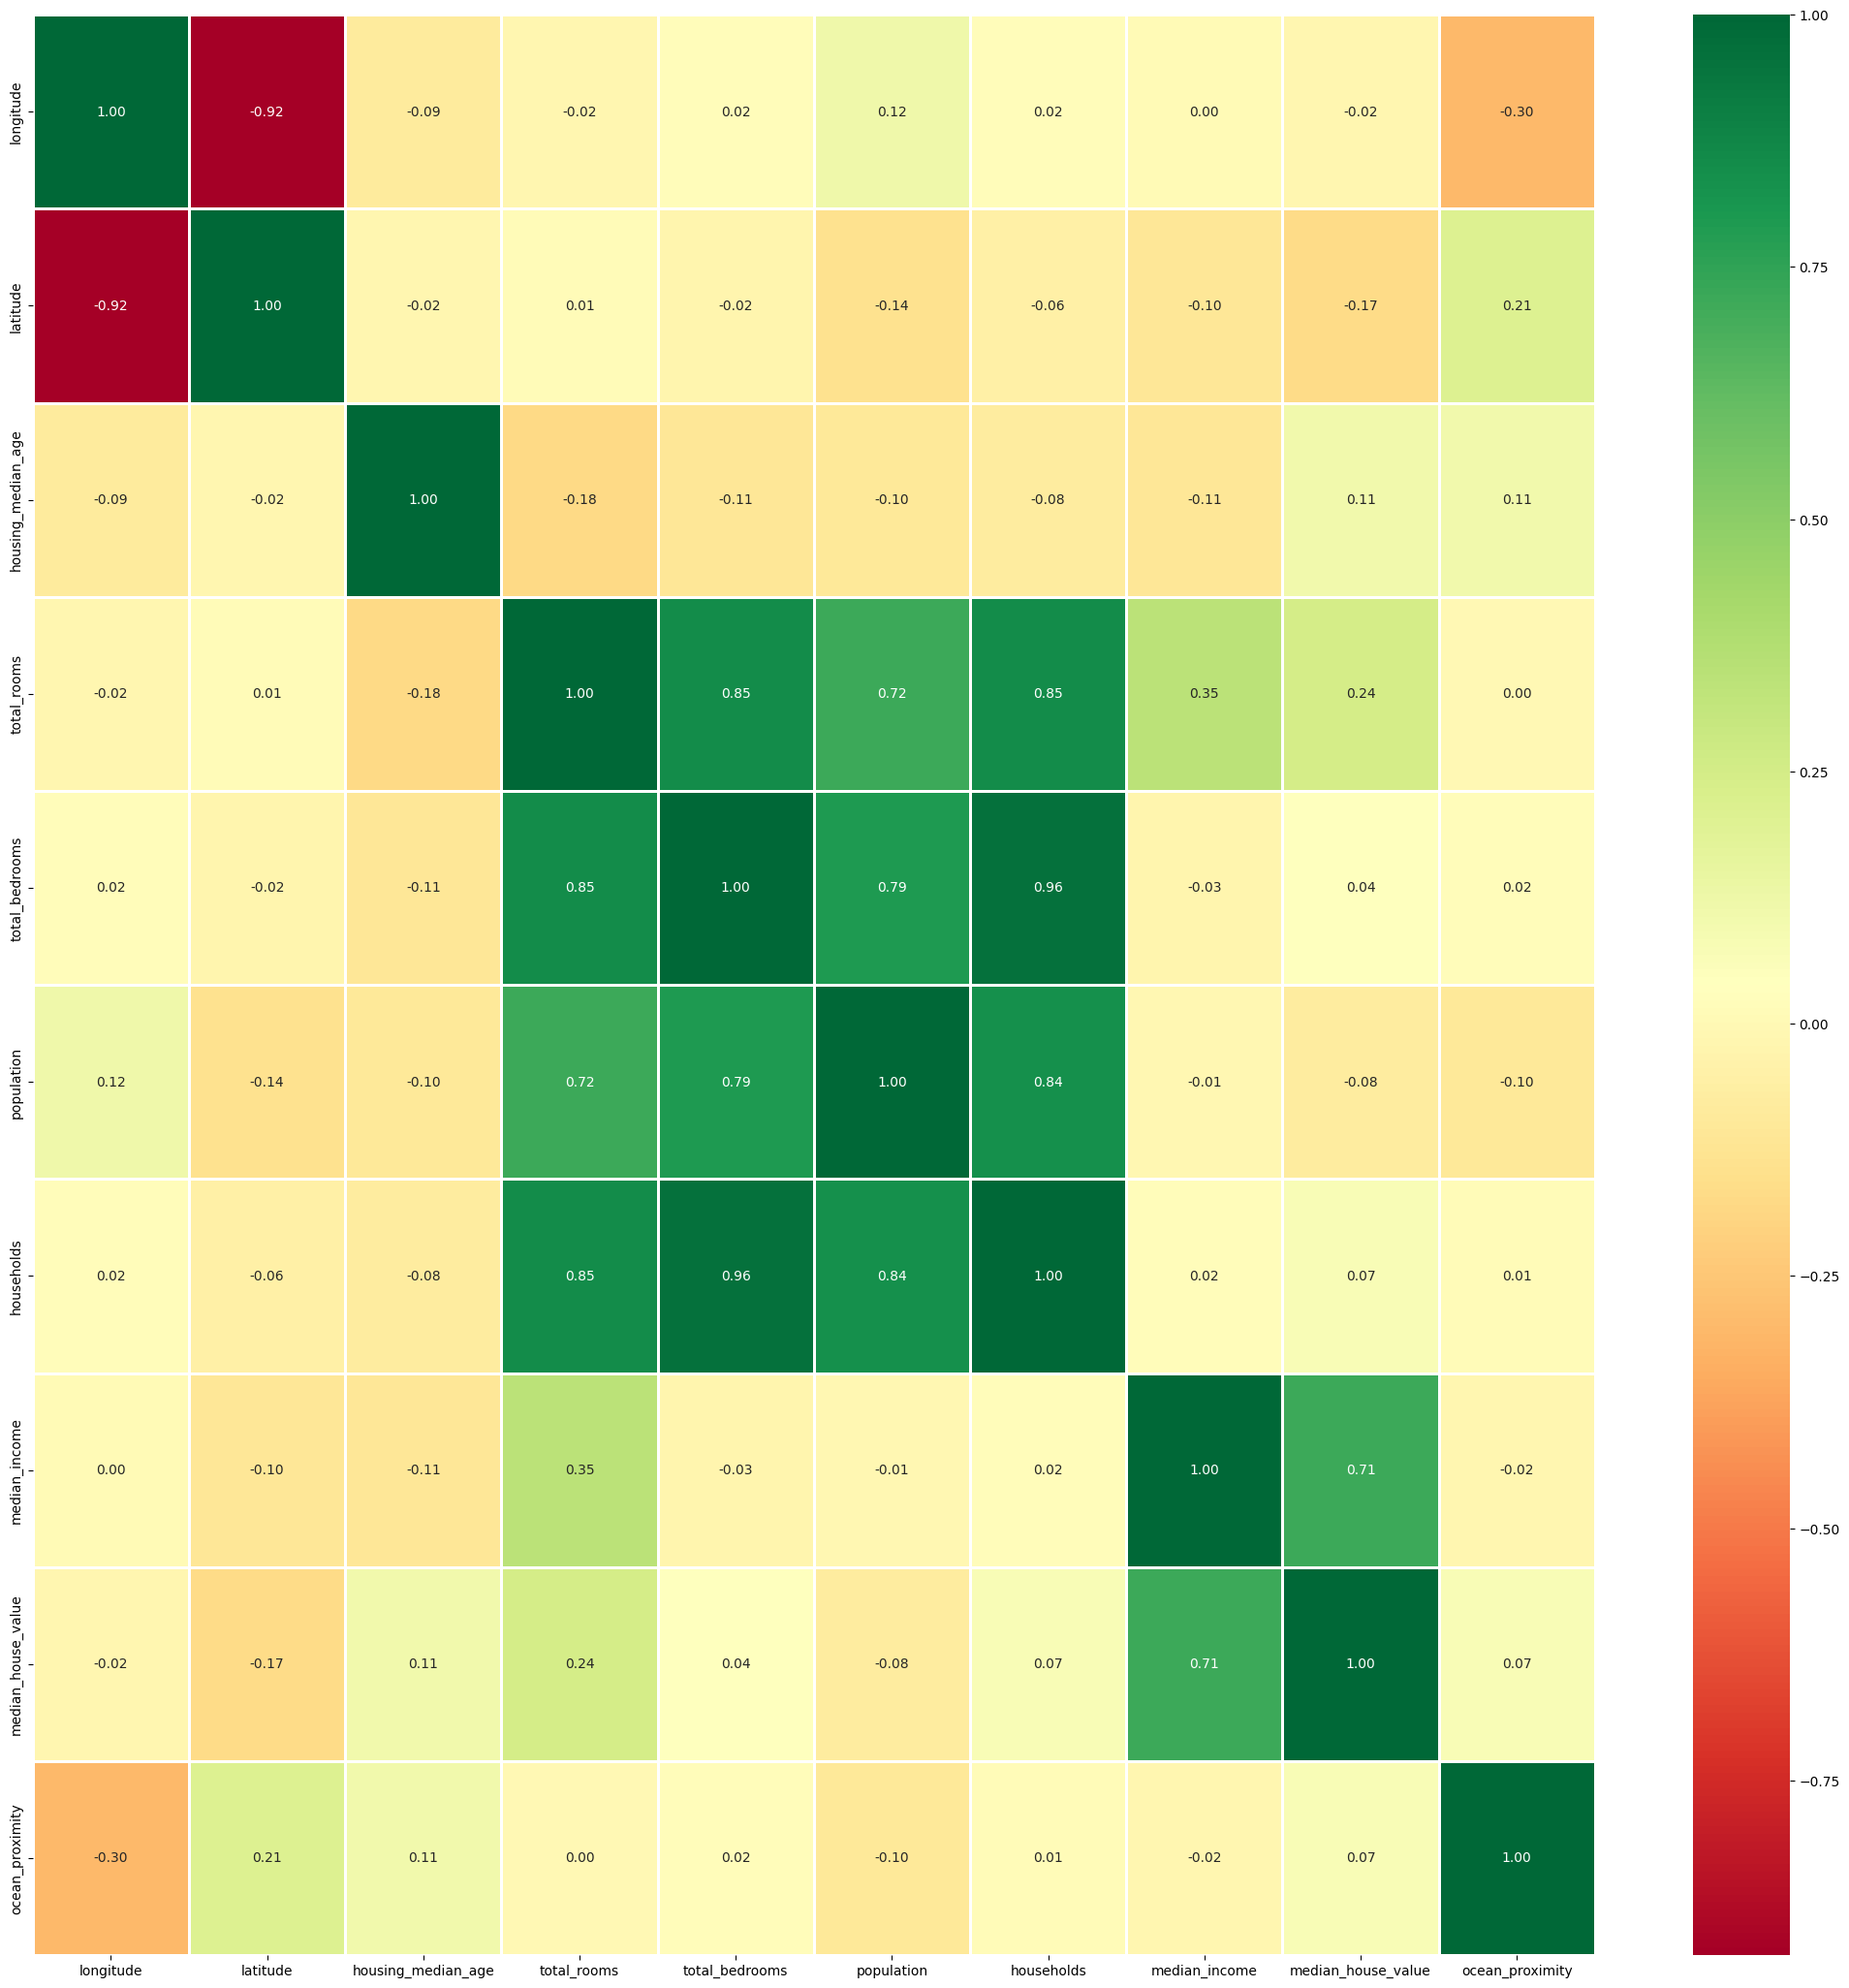

In [16]:
numeric_data = df.select_dtypes(include=np.number)

# Crea un mapa que muestra la correlación entre las diferentes variables numéricas.
f, ax = plt.subplots(figsize=(26, 26))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", linewidths=.75, ax=ax, cmap="RdYlGn")
plt.show()

In [17]:
X = df.drop([#'longitude',
             #'latitude',
             #'housing_median_age',
             #'total_rooms',
             'total_bedrooms',
             #'population',
             #'households',
             #'median_income',
             'ocean_proximity',
             'median_house_value'], axis=1)#Quito diferentes variables para mejorar la predicción
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=420)

model = CatBoostRegressor(verbose=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
    
# Imprimir resultados en la consola
print(f'Model: CatBoostRegressor')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R^2): {r2}')
print('-' * 40)

Model: CatBoostRegressor
Mean Absolute Error (MAE): 30096.38638704388
R-squared (R^2): 0.8456257231477232
----------------------------------------


**Busco combinar las variables altamente correlacionadas en una nueva variable que combine su información**

In [18]:
X['family_mean'] = X['population']/X['households']#personas promedio por familia

X2 = X.drop(['total_rooms',
             'population',
             'households',
            ], axis=1) #quito las demas variables del set de datos y conservo la nueva

X_train, X_test, y_train, y_test = train_test_split(X2, y , test_size=0.2, random_state=420)

model = CatBoostRegressor(verbose=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
    
# Imprimir resultados en la consola
print(f'Model: CatBoostRegressor')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R^2): {r2}')
print('-' * 40)

Model: CatBoostRegressor
Mean Absolute Error (MAE): 29467.304133284404
R-squared (R^2): 0.8515180628426265
----------------------------------------


La nueva variable aumenta la presición, por lo que voy a conservarla.

**Para tratar de mejorar el resultado busco ajustar los hiperparámetros del modelo** (para esta parte me ayudé con ChatGPT)

/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.10/site-packages/catboost/core.py", line 5703, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, sample_weight, None, None, None, None, baseline,
  File "/opt/conda/lib/python3.10/site-packages/catboost/core.py", line 2303, in _fit
    train_para

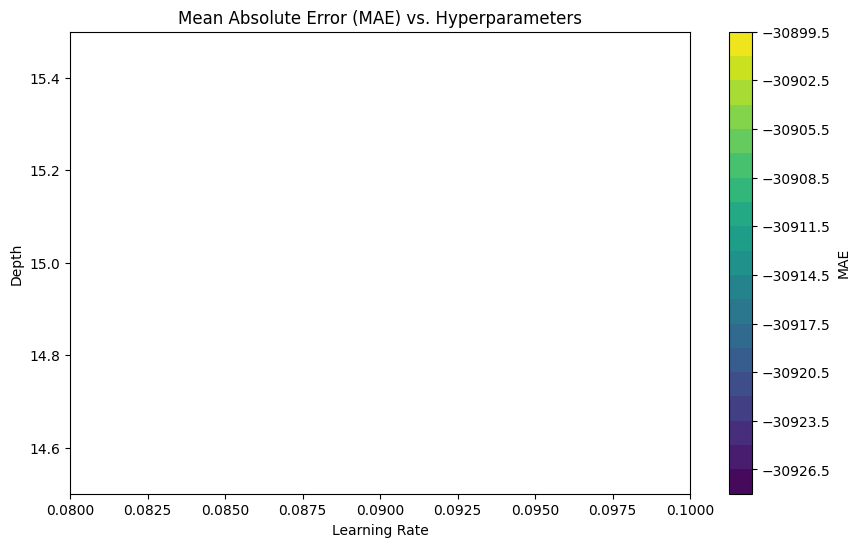

In [19]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X2, y , test_size=0.2, random_state=420)

# Defino la cuadrícula con los valores de hiperparámetros a explorar
param_grid = {
    'learning_rate': [0.08, 0.09, 0.10],
    'depth': [14.5,15,15.5],
    'iterations': [300],#100, 200, 300],
    'l2_leaf_reg': [5]#1, 3, 5]  # Regularización -> Evita el sobreajuste del modelo
}

# Crear el modelo de CatBoost
catboost = CatBoostRegressor(verbose=False)

# Definir el objeto GridSearchCV
grid_search = GridSearchCV(estimator=catboost, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error')

# Entrenar el modelo de CatBoost con búsqueda de cuadrícula
grid_search.fit(X_train, y_train)

# Obtener los resultados de la búsqueda de cuadrícula
results = grid_search.cv_results_
params = results['params']
mean_mae = results['mean_test_score']

learning_rates = [param['learning_rate'] for param in params]
depths = [param['depth'] for param in params]

# Crear una cuadrícula para los valores de los hiperparámetros
learning_rates_unique = np.unique(learning_rates)
depths_unique = np.unique(depths)
X, Y = np.meshgrid(learning_rates_unique, depths_unique)

# Crear una matriz para los errores de validación cruzada
Z = np.zeros((len(learning_rates_unique), len(depths_unique)))
for i, lr in enumerate(learning_rates_unique):
    for j, d in enumerate(depths_unique):
        idx = np.where((np.array(learning_rates) == lr) & (np.array(depths) == d))
        Z[i, j] = np.mean(mean_mae[idx])

# Crear el gráfico de contorno
fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
fig.colorbar(contour, ax=ax, label='MAE')

# Añadir etiquetas y título
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Depth')
ax.set_title('Mean Absolute Error (MAE) vs. Hyperparameters')

plt.show()

In [20]:
# Encontrar los índices de los hiperparámetros con el menor MAE
best_idx = np.unravel_index(np.argmin(Z), Z.shape)

# Obtener los hiperparámetros correspondientes a los índices encontrados
best_learning_rate = learning_rates_unique[best_idx[0]]
best_depth = depths_unique[best_idx[1]]

print("Mejores hiperparámetros encontrados:")
print("Learning Rate:", best_learning_rate)
print("Depth:", best_depth)

# Entrenar el modelo final con los mejores hiperparámetros
best_params = grid_search.best_params_
best_catboost = CatBoostRegressor(**best_params, verbose=False)
best_catboost.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = best_catboost.predict(X_test)

# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

Mejores hiperparámetros encontrados:
Learning Rate: 0.08
Depth: 14.5


In [21]:
# Imprimir resultados en la consola
print(f'Model: CatBoostRegressor')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R-squared (R^2): {r2}')
print('-' * 40)

Model: CatBoostRegressor
Mean Absolute Error (MAE): 30121.01142845553
R-squared (R^2): 0.8433387765429203
----------------------------------------


In [22]:
np.max(Z)

nan